Training 1D Convolutional Denoising Autoencoder...
Epoch [10/60] - Reconstruction MSE Loss: 0.017656
Epoch [20/60] - Reconstruction MSE Loss: 0.008753
Epoch [30/60] - Reconstruction MSE Loss: 0.006095
Epoch [40/60] - Reconstruction MSE Loss: 0.004774
Epoch [50/60] - Reconstruction MSE Loss: 0.004117
Epoch [60/60] - Reconstruction MSE Loss: 0.003771


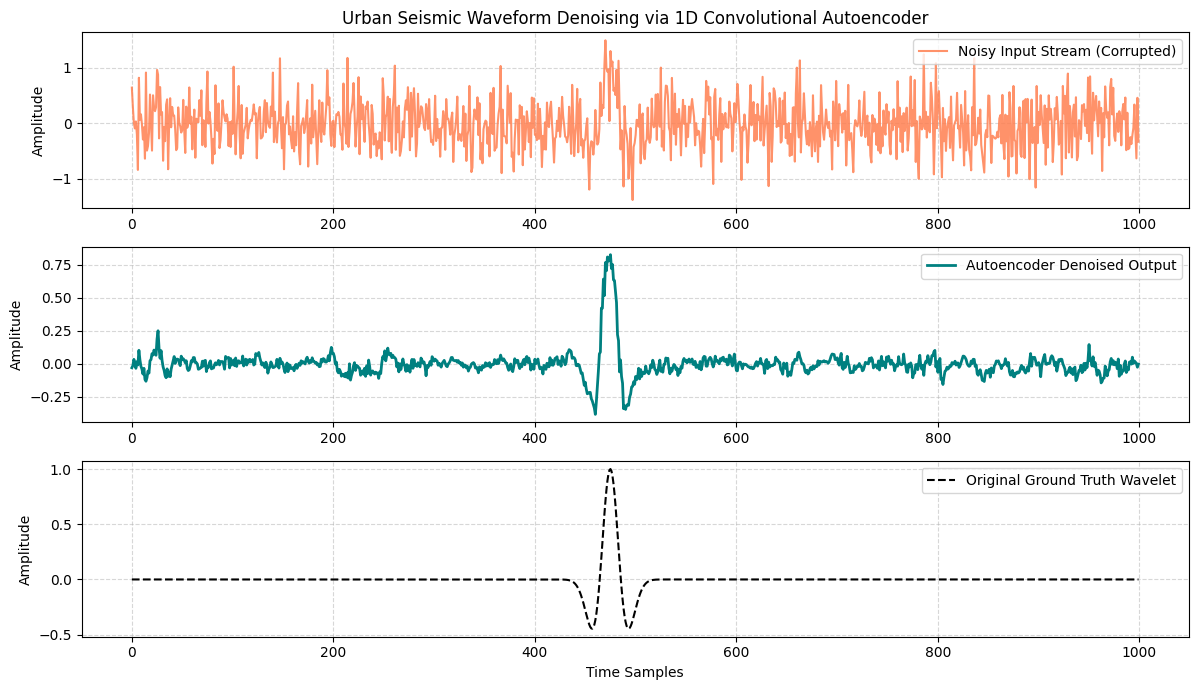

Denoising plot successfully saved to '../images/step5_denoising_autoencoder.png'


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


os.makedirs('../images', exist_ok=True)  #Ensures target directories exist


#1 Defining the 1D Convolutional Autoencoder Architecture

class SeismicDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(SeismicDenoisingAutoencoder, self).__init__()
        
        # Encoder: Compresses 1000 time-series samples down to a latent space
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # Shape: [Batch, 16, 500]
            
            nn.Conv1d(16, 32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)   # Shape: [Batch, 32, 250]
        )
        
        # Decoder: Reconstructs clean signal back to original size [Batch, 1, 1000]
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'), # Shape: [Batch, 32, 500]
            nn.Conv1d(32, 16, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='nearest'), # Shape: [Batch, 16, 1000]
            nn.Conv1d(16, 1, kernel_size=7, stride=1, padding=3)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


#2 Generating Synthetic Ground Truth & Heavy Noisy Seismic Data

np.random.seed(42)
torch.manual_seed(42)

num_samples = 200
signal_len = 1000
t = np.linspace(-1, 1, signal_len)

clean_signals = []
noisy_signals = []

for _ in range(num_samples):
    # Random shift and frequency for synthetic Ricker-like seismic pulse
    shift = np.random.uniform(-0.3, 0.3)
    freq = np.random.uniform(10, 20)
    pulse = (1 - 2 * (np.pi * freq * (t - shift))**2) * np.exp(-(np.pi * freq * (t - shift))**2)
    
    # Heavy urban background noise
    noise = np.random.normal(0, 0.4, signal_len)
    
    clean_signals.append(pulse)
    noisy_signals.append(pulse + noise)

# Converting to PyTorch Tensors [Batch, Channels, Length]
X_clean = torch.tensor(np.array(clean_signals), dtype=torch.float32).unsqueeze(1)
X_noisy = torch.tensor(np.array(noisy_signals), dtype=torch.float32).unsqueeze(1)


#3 Training the Autoencoder Model

model = SeismicDenoisingAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

epochs = 60
print("Training 1D Convolutional Denoising Autoencoder...")

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_noisy)
    
    # Loss is calculated against the CLEAN ground truth target
    loss = criterion(outputs, X_clean)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Reconstruction MSE Loss: {loss.item():.6f}")


#4 Visualizing & Saving Denoising Results

model.eval()
with torch.no_grad():
    denoised_outputs = model(X_noisy).numpy()

test_idx = 5  # Picking a sample wave to plot

plt.figure(figsize=(12, 7))

# Plot 1: Noisy Input Signal
plt.subplot(3, 1, 1)
plt.plot(X_noisy[test_idx, 0, :].numpy(), color='coral', alpha=0.85, label='Noisy Input Stream (Corrupted)')
plt.title('Urban Seismic Waveform Denoising via 1D Convolutional Autoencoder')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Plot 2: Cleaned Output from Autoencoder
plt.subplot(3, 1, 2)
plt.plot(denoised_outputs[test_idx, 0, :], color='teal', linewidth=2, label='Autoencoder Denoised Output')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Plot 3: Ground Truth Target
plt.subplot(3, 1, 3)
plt.plot(X_clean[test_idx, 0, :].numpy(), color='black', linestyle='--', label='Original Ground Truth Wavelet')
plt.xlabel('Time Samples')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()

output_plot_path = '../images/step5_denoising_autoencoder.png'
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Denoising plot successfully saved to '{output_plot_path}'")